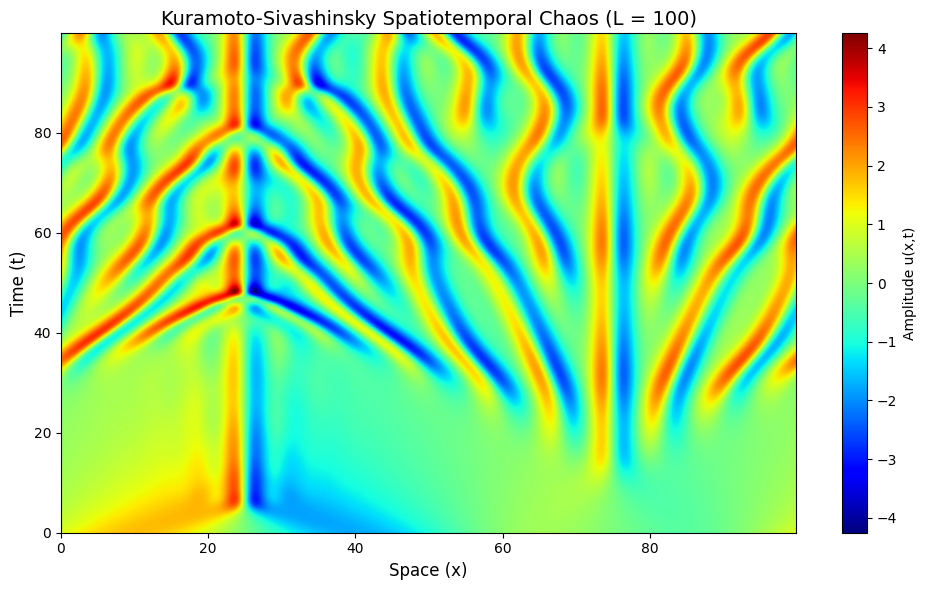

In [1]:
#first we have to make an fft based spectral solver for ks equation
from matplotlib import colors
import numpy as np
from scipy.integrate import solve_ivp
def KS_solver(x, t, u_0):
  N = len(x)

  dx = x[1]-x[0]
  k = 2*np.pi*np.fft.fftfreq(N, dx)

  u_0hat = np.fft.fft(u_0)
  u_0hatri = np.concatenate((u_0hat.real, u_0hat.imag)) # Fixed TypeError: Removed .dtype=complex
  def rhs_heat(t,u_hat_ri, k):
    u_hat = u_hat_ri[:N] + (1j)*u_hat_ri[N:]
    lin = (k**2 - k**4) * u_hat
    u = np.fft.ifft(u_hat)
    u2_hat = np.fft.fft(u * u)
    nonlin = -0.5j * k * u2_hat

    dt_u_hat = lin + nonlin
    dt_u_hatri = np.concatenate((dt_u_hat.real,dt_u_hat.imag))
    return dt_u_hatri
  sol = solve_ivp(rhs_heat, (t[0],t[-1]),u_0hatri,t_eval=t, method = 'BDF',args = (k,))
  u_hat_ri = np.zeros((len(t),len(x)))
  u_hat_ri = sol.y.T # Fixed to correctly extract solution array
  u_hat = u_hat_ri[:,:N] + (1j)*u_hat_ri[:,N:]
  u = np.zeros_like(u_hat)
  for k in range(len(t)):
    u[k, :] = np.fft.ifft(u_hat[k,:])
  u = u.real
  return u
#lets test it first
x = np.arange(0,100,0.1)
dx = x[1]-x[0]
L = x[-1] - x[0] + dx
t = np.arange(0,100,0.1)
u_0 = np.zeros_like(x)
for i in range(len(u_0)):
  u_0[i] = np.cos(2*np.pi*x[i]/L)*(1+2*np.sin(2*np.pi*x[i]/L))
u = KS_solver(x,t,u_0)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.pcolormesh(x, t, u, shading='gouraud', cmap='jet')
plt.xlabel('Space (x)', fontsize=12)
plt.ylabel('Time (t)', fontsize=12)
plt.title('Kuramoto-Sivashinsky Spatiotemporal Chaos (L = 100)', fontsize=14)
plt.colorbar(label='Amplitude u(x,t)')
plt.tight_layout()
plt.show()

In [10]:
#Now we have to define the cnn algorithm, we would divide the system into three major domains in terms of length.
#we would have a 2d input for the cnn, with x and t being the 2 dimensions with values of u
#now lets define the cnn architecture
import torch.nn as nn
import torch
class CNN(nn.Module):
  def __init__(self, kernel_size=(2,2),stride=(1,1)):
    super().__init__()
    padding = (kernel_size[0] // 2, kernel_size[1] // 2)
    self.conv_layers = nn.Sequential(nn.Conv2d(1,32,kernel_size,stride,padding),nn.ReLU(),nn.MaxPool2d((2,2)),\
              nn.Conv2d(32,32,(3,3),stride,(1,1)), nn.ReLU(), nn.MaxPool2d((2,2)), nn.AdaptiveAvgPool2d((1,1)))
    self.linear_layers = nn.Sequential(nn.Linear(32,16), nn.ReLU(), nn.Dropout(p=0.2),nn.Linear(16,3))
  def forward(self, input_tensor):
    input = self.conv_layers(input_tensor)
    input = torch.flatten(input,start_dim=1)
    output = self.linear_layers(input)
    return output

criterion = nn.CrossEntropyLoss()

In [5]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
regimes = [(16.0, 0), (28.0, 1), (100.0, 2)]
patch_h, patch_w = 64, 64
patches, labels = [], []

for L, label in regimes:
    x = np.arange(0, L, 0.1)
    t = np.arange(0, 100, 0.1)
    u_0 = np.cos(2 * np.pi * x / L) * (1 + 2 * np.sin(2 * np.pi * x / L))

    u = KS_solver(x, t, u_0)[300:, :]
    for i in range(0, u.shape[0] - patch_h, 32):
        for j in range(0, u.shape[1] - patch_w, 32):
            patches.append(u[i : i + patch_h, j : j + patch_w])
            labels.append(label)

X = np.array(patches, dtype=np.float32)
X = (X - X.mean()) / X.std()
X_tensor = torch.tensor(X).unsqueeze(1)
y_tensor = torch.tensor(labels, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

kernel_size: (3, 3), epoch 4, loss 0.7609271794557572
kernel_size: (3, 3), epoch 9, loss 0.7155802249908447
kernel_size: (3, 3), epoch 14, loss 0.624730221927166
kernel_size: (3, 3), epoch 19, loss 0.588372990489006
kernel_size: (3, 3), epoch 24, loss 0.5226876214146614
kernel_size: (3, 3), epoch 29, loss 0.51308618709445
kernel_size: (3, 3), epoch 34, loss 0.4984450936317444
kernel_size: (3, 3), epoch 39, loss 0.4901184916496277
kernel_size: (3, 3), epoch 44, loss 0.46815083622932435
kernel_size: (3, 3), epoch 49, loss 0.4574523612856865
kernel_size: (3, 7), epoch 4, loss 0.7623435616493225
kernel_size: (3, 7), epoch 9, loss 0.6963234543800354
kernel_size: (3, 7), epoch 14, loss 0.6249506011605263
kernel_size: (3, 7), epoch 19, loss 0.5553514257073402
kernel_size: (3, 7), epoch 24, loss 0.523891331255436
kernel_size: (3, 7), epoch 29, loss 0.4791918069124222
kernel_size: (3, 7), epoch 34, loss 0.4407087884843349
kernel_size: (3, 7), epoch 39, loss 0.3747666411101818
kernel_size: (3, 7

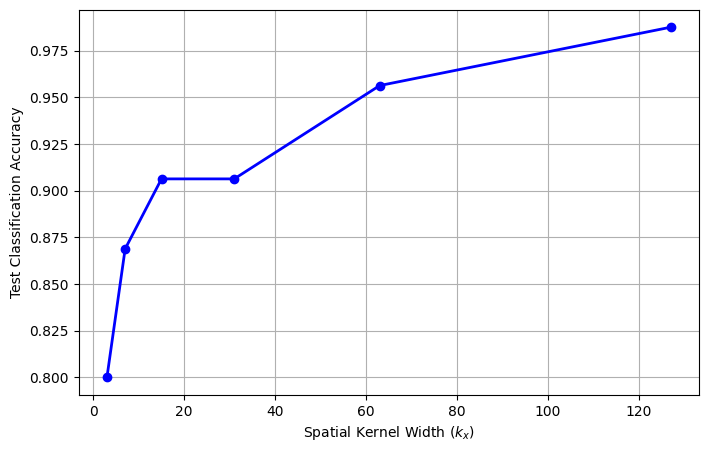

In [8]:
kernels = [(3, 3), (3, 7), (3, 15), (3, 31), (3, 63), (3, 127)]
epochs = 50
accuracy = []
for k in kernels:

  cnn_model = CNN(k)
  cnn_model.train()
  optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
  for epoch in range(epochs):
      running_loss = 0.0
      for X_batch,y_batch in train_loader:
        optimizer.zero_grad()
        logits = cnn_model(X_batch)
        loss = criterion(logits, y_batch)
        running_loss+=loss.item()
        loss.backward()
        optimizer.step()
      avg_loss = running_loss/len(train_loader)
      if (epoch+1)%5==0:
        print(f"kernel_size: {k}, epoch {epoch}, loss {avg_loss}")
  cnn_model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for X_test, y_test in test_loader:
      output = cnn_model(X_test)
      preds = torch.argmax(output, dim=1)
      correct+=(preds==y_test).sum().item()
      total+=y_test.size(0)
  accuracy.append([correct/total])
spatial_k_widths = [k[1] for k in kernels]

plt.figure(figsize=(8, 5))
plt.plot(spatial_k_widths, accuracy, marker='o', linewidth=2, color='b')
plt.xlabel("Spatial Kernel Width ($k_x$)")
plt.ylabel("Test Classification Accuracy")
plt.grid(True)
plt.show()
